In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json

from pathlib import Path
import re

from jupyters.visu_utils import load_sts_merged_mteb
from visu_utils import TASK_LIST_CLASSIFICATION, make_results_tables_per_group_size, load_classification_merged_mteb, \
    load_clustering_merged_mteb


from autorank import autorank, plot_stats, create_report, latex_table

EXPORT_PATH_TABLE = Path("../../papers/Distillation-MI-ICLR/tables/nlp/")
EXPORT_PATH_FIG = Path("../../papers/Distillation-MI-ICLR/figures/nlp/")

# Make sure the folders exist
EXPORT_PATH_TABLE.mkdir(parents=True, exist_ok=True)
EXPORT_PATH_FIG.mkdir(parents=True, exist_ok=True)

%reload_ext autoreload
%autoreload 2

models = ['paraphrase-multilingual', 'msmarco', 'ALL', "m-v1.5", "unsup-sim"]
plt.rc('text', usetex=True)
plt.rc('text.latex', preamble=r'\usepackage{lmodern}')


In [172]:

EXPORT_PATH_TABLE = Path("../../papers/Distillation-MI-ICLR/tables/nlp/")
EXPORT_PATH_FIG = Path("../../papers/Distillation-MI-ICLR/figures/nlp/")

# Make sure the folders exist
EXPORT_PATH_TABLE.mkdir(parents=True, exist_ok=True)
EXPORT_PATH_FIG.mkdir(parents=True, exist_ok=True)


CSV_PATH = "global_table.csv"



df = pd.read_csv(CSV_PATH)
# 
label_mapping = {
    "TweetSentimentExtraction": "TweetSE",
    "ArxivP2P": "ArxivP2P",
    "ArxivS2S": "ArxivS2S",
    "Reddit": "Reddit",
    "Imdb": "Imdb",
    "MTOPIntent": "MTOPI",
    "TwentyNewsgroups": "TwentyNG",
    "RedditP2P": "RedditP2P",
    "AmazonPolarity": "AmazonPol.",
    "StackExchangeP2P": "StackExP2P",
    "StackExchange": "StatEx",
    "Banking77": "Banking77",
    "ToxicConversations": "ToxicConv",
    "MassiveIntent": "MassInt",
    "MTOPDomain": "MTOPD",
    "AmazonCounterfactual": "AmazonCF",
    "MassiveScenario": "MassScen",
    "\\textbf{Avg. Clustering}": "\\textbf{Avg. Clust}",
    "Emotion": "Emotion",
    "AmazonReviews": "AmazonR",
    "\\textbf{Avg. Classif}": "\\textbf{Avg. Classif}"
}


name_mapping = {
    'instructor-base': 'Instructor Base',
    'bge-base-en-v1.5': 'BGE Base EN v1.5',
    'stella_en_400M_v5': 'Stella EN 400M v5',
    'gte-small': 'GTE Small',
    'gte-base': 'GTE Base',
    'all-MiniLM-L6-v2': 'MiniLM L6 v2',
    '\\textbf{Student-xs - NLL}': '\\textbf{Stud. XS NLL}',
    'e5-small': 'E5 Small',
    '\\textbf{Student-m - NLL}': '\\textbf{Stud. M NLL}',
    '\\textbf{Student-xs - MSE}': '\\textbf{Stud. XS MSE}',
    'bge-small-en-v1.5': 'BGE Small EN v1.5',
    'e5-base-4k': 'E5 Base 4k',
    'GIST-all-MiniLM-L6-v2': 'GIST MiniLM',
    'NoInstruct-small-Embedding-v0': 'NoInstruct Small Embed v0',
    '\\textbf{Student-s - NLL}': '\\textbf{Stud. S NLL}',
    '\\textbf{Student-l - NLL}': '\\textbf{Stud. L NLL}',
    'GIST-Embedding-v0': 'GIST Embed v0',
    'gte-tiny': 'GTE Tiny',
    'snowflake-arctic-embed-m': 'Snowflake M',
    'e5-small-v2': 'E5 Small v2',
    'GIST-small-Embedding-v0': 'GIST Small Embed v0',
    'e5-base': 'E5 Base',
    '\\textbf{Student-s - MSE}': '\\textbf{Stud. S MSE}',
    'Ivysaur': 'Ivysaur',
    'slx-v0.1': 'SLX v0.1',
    '\\textbf{Student-m - MSE}': '\\textbf{Stud. M MSE}',
    'gte-large-en-v1.5': 'GTE Large EN v1.5',
    'multilingual-e5-small': 'Multilingual E5 Small',
    'instructor-large': 'Instructor Large',
    'snowflake-arctic-embed-xs': 'Snowflake XS',
    'MUG-B-1.6': 'MUG B 1.6',
    'jina-embeddings-v2-base-en': 'Jina Embed Base EN',
    'e5-base-v2': 'E5 Base v2',
    'gte-base-en-v1.5': 'GTE Base EN v1.5',
    'UAE-Large-V1': 'UAE Large V1',
    'GIST-large-Embedding-v0': 'GIST Large Embed v0',
    'jina-embeddings-v2-small-en': 'Jina Embed Small EN',
    'sentence-t5-base': 'Sentence T5 Base',
    'mxbai-embed-large-v1': 'MXBAI Embed Large v1',
    'gtr-t5-large': 'GTR T5 Large',
    'gte-large': 'GTE Large',
    'sf_model_e5': 'SF Model E5',
    'LASER': 'LASER',
    'snowflake-arctic-embed-l': 'Snowflake L',
    'all-mpnet-base-v2': 'MPNet Base v2',
    'b1ade-embed': 'B1ADE Embed',
    'e5-large-v2': 'E5 Large v2',
    'ember-v1': 'Ember v1',
    'stella-base-en-v2': 'Stella Base EN v2',
    'bge-large-en-v1.5': 'BGE Large EN v1.5',
    'snowflake-arctic-embed-s': 'Snowflake Embed S',
    'Angle_BERT': 'Angle BERT',
    'sup-simcse-bert-base-uncased': 'Sup SimCSE BERT Base',
    'multilingual-e5-base': 'Multilingual E5 Base',
    'nomic-embed-text-v1-ablated': 'Nomic Embed Text v1 Ablated',
    'all-MiniLM-L12-v2': 'MiniLM L12 v2',
    'snowflake-arctic-embed-m-long': 'Snowflake Embed M Long',
    'snowflake-arctic-embed-m-v1.5': 'Snowflake Embed M v1.5',
    'b1ade-embed-kd': 'B1ADE Embed KD',
    'jina-embedding-b-en-v1': 'Jina Embed B EN v1',
    'multi-qa-MiniLM-L6-cos-v1': 'Multi QA MiniLM',
    'Wartortle': 'Wartortle',
    'sentence-t5-large': 'Sentence T5 Large',
    'bilingual-embedding-base': 'Bilingual Embed Base',
    'bge-small-4096': 'BGE Small 4096',
    'mxbai-embed-2d-large-v1': 'MXBAI Embed 2D Large v1',
    'rubert-tiny-turbo': 'RuBERT Tiny Turbo',
    'e5-large': 'E5 Large',
    'gtr-t5-base': 'GTR T5 Base',
    'nomic-embed-text-v1': 'Nomic Embed Text v1',
    'contriever-base-msmarco': 'Contriever Base MSMARCO',
    'nomic-embed-text-v1-unsupervised': 'Nomic Embed Text v1 Unsup',
    'bert-base-uncased': 'BERT Base Uncased',
    'ml-nlp-elser.html': 'ML NLP Elser',
    'msmarco-bert-co-condensor': 'MSMARCO BERT Co-Condensor',
    'unsup-simcse-bert-base-uncased': 'Unsup SimCSE BERT Base',
    'allenai-specter': 'AllenAI Specter',
    'bilingual-embedding-small': 'Bilingual Embed Small',
    'Squirtle': 'Squirtle',
    'jina-embedding-s-en-v1': 'Jina Embed S EN v1',
    'gte-multilingual-base': 'GTE Multilingual Base',
    'embedder-100p': 'Embedder 100p',
    'fin-mpnet-base': 'Fin MPNet Base',
    'jina-embedding-l-en-v1': 'Jina Embed L EN v1',
    'paraphrase-multilingual-MiniLM-L12-v2': 'Paraphrase Multi MiniLM L12 v2',
    'jina-embeddings-v2-base-es': 'Jina Embed Base ES',
    'paraphrase-multilingual-mpnet-base-v2': 'Paraphrase Multi MPNet Base v2',
    'text2vec-base-multilingual': 'Text2Vec Base Multi',
    'cai-stellaris-text-embeddings': 'CAI Stellaris Text Embed',
    'bge-micro': 'BGE Micro',
    'bge-micro-v2': 'BGE Micro v2',
    'gte-micro': 'GTE Micro',
    'jina-embeddings-v2-base-de': 'Jina Embed Base DE',
    '\\textbf{Student-l - MSE}': '\\textbf{Student L MSE}',
    'Venusaur': 'Venusaur',
    'distiluse-base-multilingual-cased-v2': 'DistilUSE Base Multi Cased v2',
    'lodestone-base-4096-v1': 'Lodestone Base 4096 v1',
    'nomic-embed-text-v1.5': 'Nomic Embed Text v1.5',
    'Bulbasaur': 'Bulbasaur',
    'gte-micro-v4': 'GTE Micro v4',
    'ALL_862873': 'ALL 862873',
    'gte-micro-v2': 'GTE Micro v2',
    'gte-micro-v3': 'GTE Micro v3',
    'average_word_embeddings_komninos': 'Avg Word Embed Komninos',
    'SGPT-125M-weightedmean-msmarco-specb-bitfit': 'SGPT 125M WeightedMean MSMARCO SpecB BitFit',
    'SGPT-125M-weightedmean-nli-bitfit': 'SGPT 125M WeightedMean NLI BitFit',
    'LaBSE-en-ru': 'LaBSE EN-RU',
    'b1ade-embed-kd_3': 'B1ADE Embed KD 3'
}

# df['Task'] = df['Task'].map(label_mapping)
df['Model'].unique()



array(['instructor-base', 'bge-base-en-v1.5', 'stella_en_400M_v5',
       'gte-small', 'gte-base', 'all-MiniLM-L6-v2',
       '\\textbf{Student-xs - NLL}', 'e5-small',
       '\\textbf{Student-m - NLL}', '\\textbf{Student-xs - MSE}',
       'bge-small-en-v1.5', 'e5-base-4k', 'GIST-all-MiniLM-L6-v2',
       'NoInstruct-small-Embedding-v0', '\\textbf{Student-s - NLL}',
       '\\textbf{Student-l - NLL}', 'GIST-Embedding-v0', 'gte-tiny',
       'snowflake-arctic-embed-m', 'e5-small-v2',
       'GIST-small-Embedding-v0', 'e5-base', '\\textbf{Student-s - MSE}',
       'Ivysaur', 'slx-v0.1', '\\textbf{Student-m - MSE}',
       'gte-large-en-v1.5', 'multilingual-e5-small', 'instructor-large',
       'snowflake-arctic-embed-xs', 'MUG-B-1.6',
       'jina-embeddings-v2-base-en', 'e5-base-v2', 'gte-base-en-v1.5',
       'UAE-Large-V1', 'GIST-large-Embedding-v0',
       'jina-embeddings-v2-small-en', 'sentence-t5-base',
       'mxbai-embed-large-v1', 'gtr-t5-large', 'gte-large', 'sf_model_e5',
  

In [ ]:
df

In [180]:


def make_rank_heatmap_with_mask(df_rank, ax, common_kwargs):
    # make a mask that is True for the best value per line
    
    mask = np.zeros(df_rank.shape, dtype=bool)
    
    for i in range(df_rank.shape[0]):
        mask[i, df_rank.iloc[i].argmin()] = True
    

    annot_underline = np.empty(df_rank.shape, dtype=object)
    for i in range(df_rank.shape[0]):
        for j in range(df_rank.shape[1]):
            annot_underline[i, j] = f"\\textbf{{\\underline{{{df_rank.iloc[i, j]:.0f}}}}}"

    annot = np.empty(df_rank.shape, dtype=object)
    for i in range(df_rank.shape[0]):
        for j in range(df_rank.shape[1]):
            annot[i, j] = f"{df_rank.iloc[i, j]:.0f}"

    # format the sns with underline 
    g1 = sns.heatmap(df_rank, ax=ax, cmap='flare', annot_kws={"size": 16, "rotation":0}, annot=annot_underline, fmt="", cbar=False,
                mask=~mask,vmin=1, vmax=12, **common_kwargs)

    # format the sns with the values
    g2 = sns.heatmap(df_rank, ax=ax, cmap='flare', annot_kws={"size": 16, "rotation": 0}, annot=annot, fmt="", cbar=False, mask=mask, vmin=1, vmax=12,
                **common_kwargs)

    return g1, g2



In [152]:




df['Task'].unique()



array(['TweetSE', 'ArxivP2P', 'ArxivS2S', 'Reddit', 'Imdb', 'MTOPI',
       'TwentyNG', 'RedditP2P', 'AmazonPol.', 'StackExP2P', 'StatEx',
       'Banking77', 'ToxicConv', 'MassInt', 'MTOPD', 'AmazonCF',
       'MassScen', 'Avg. Clustering', 'Emotion', 'AmazonR',
       'Avg. Classif'], dtype=object)

Task,AmazonCounterfactual,AmazonPolarity,AmazonReviews,Banking77,Emotion,Imdb,MTOPDomain,MTOPIntent,MassiveIntent,MassiveScenario,ToxicConversations,TweetSentimentExtraction,\textbf{Avg. Classif}
Model,,,,,,,,,,,,,
GIST-all-MiniLM-L6-v2,2.0,1.0,3.0,2.0,3.0,5.0,2.0,2.0,3.0,3.0,1.0,2.0,2.416667
Ivysaur,3.0,2.0,1.0,4.0,4.0,3.0,4.0,4.0,4.0,4.0,5.0,4.0,3.500000
\textbf{Student-xs - MSE},5.0,4.0,5.0,3.0,2.0,1.0,3.0,3.0,2.0,1.0,4.0,3.0,3.000000
\textbf{Student-xs - NLL},1.0,5.0,4.0,1.0,1.0,2.0,1.0,1.0,1.0,2.0,3.0,1.0,1.916667
all-MiniLM-L6-v2,7.0,8.0,7.0,6.0,7.0,7.0,7.0,7.0,7.0,7.0,8.0,8.0,7.166667
gte-tiny,4.0,3.0,2.0,5.0,5.0,4.0,6.0,5.0,5.0,5.0,2.0,5.0,4.250000
multi-qa-MiniLM-L6-cos-v1,8.0,9.0,9.0,7.0,9.0,8.0,9.0,8.0,8.0,8.0,6.0,9.0,8.166667
slx-v0.1,9.0,8.0,8.0,6.0,8.0,7.0,5.0,6.0,6.0,6.0,8.0,8.0,7.083333
snowflake-arctic-embed-xs,6.0,6.0,6.0,8.0,6.0,6.0,8.0,9.0,9.0,9.0,7.0,6.0,7.166667


Task,ArxivP2P,ArxivS2S,Reddit,RedditP2P,StackExchange,StackExchangeP2P,TwentyNewsgroups,\textbf{Avg. Clustering}
Model,,,,,,,,
GIST-all-MiniLM-L6-v2,5.0,4.0,9.0,8.0,7.0,5.0,5.0,6.142857
Ivysaur,4.0,5.0,7.0,4.0,4.0,6.0,7.0,5.285714
\textbf{Student-xs - MSE},8.0,8.0,5.0,5.0,5.0,9.0,4.0,6.285714
\textbf{Student-xs - NLL},6.0,6.0,1.0,1.0,1.0,8.0,2.0,3.571429
all-MiniLM-L6-v2,2.0,1.0,2.0,6.0,6.0,3.0,1.0,3.000000
gte-tiny,1.0,3.0,4.0,3.0,2.0,1.0,3.0,2.428571
multi-qa-MiniLM-L6-cos-v1,9.0,9.0,8.0,7.0,8.0,7.0,6.0,7.714286
slx-v0.1,3.0,2.0,3.0,6.0,6.0,4.0,1.0,3.571429
snowflake-arctic-embed-xs,7.0,7.0,6.0,2.0,3.0,2.0,8.0,5.000000


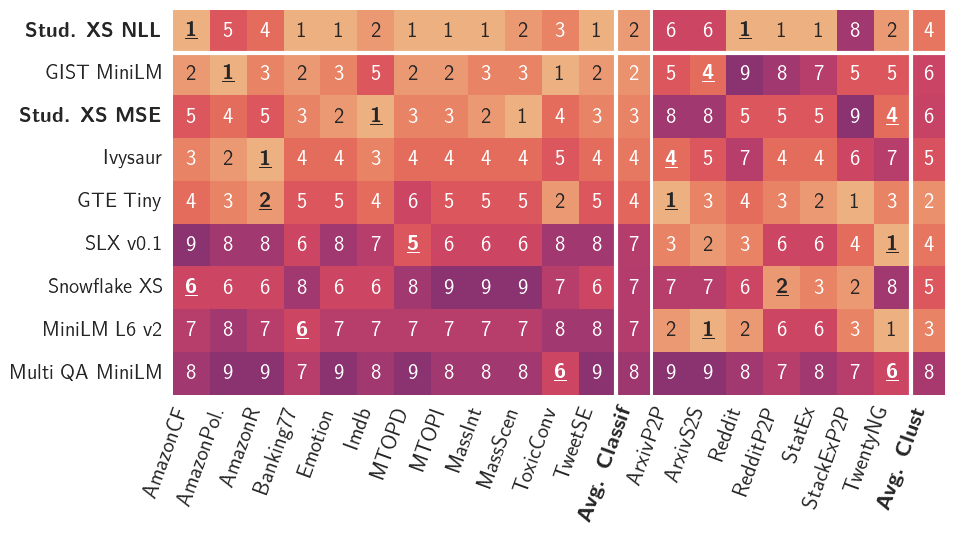

In [191]:




parameters = {'xs': {'ylabel': 15, 'task_div' : 2, 'model_div' : 2, 'xlabel': 16,},
              'm' : {'ylabel': 10, 'task_div' : 2, 'model_div' : 5, 'xlabel': 10},
               's' : {'ylabel': 16, 'task_div' : 2, 'model_div' : 5, 'xlabel': 16},
              }

for size, group in df.groupby(['Size Group']):
    if size[0] == 'l':
        continue
    if size[0] != "xs":
        continue
    n_types = group['Type'].nunique()
    
    n_models = group['Model'].nunique()
    n_tasks = group['Task'].nunique()
    
    ratios = [g['Task'].nunique() for _, g in group.groupby('Type')]
    
    # get model names ordered by Avg. Classif
    
    common_models = set(group['Model'].unique())
    
    for k, (type, group_type) in enumerate(group.groupby('Type')):
        common_models = common_models.intersection(group_type['Model'].unique())
        
    # keep only models that are in common
    common_models = [c for c in common_models if "rubert" not in c]
    group = group[group['Model'].isin(common_models)]
    

    model_order = group[(group['Task'] == '\\textbf{Avg. Classif}')].sort_values('Rank', ascending=True)['Model'].tolist()[:12]

    fig, ax = plt.subplots(1, n_types, figsize=(n_tasks // parameters[size[0]]['task_div'], n_models // parameters[size[0]]['model_div']), squeeze=True, sharey=True, sharex=False, gridspec_kw={"width_ratios":ratios})
    ax = ax.flatten()
    for k, (type, group_type) in enumerate(group.groupby('Type')):
        df_rank = group_type.pivot_table(index='Model', columns='Task', values='Rank')
        df_rank = df_rank.dropna()
        display(df_rank)
        
        # Put Avg Classif and Avg Clustering at the end
        df_rank = df_rank[
            [col for col in df_rank.columns if not col.startswith('Avg')] + [col for col in df_rank.columns if
                                                                             col.startswith('Avg')]]
        
        ax[k].axvline(x=len(df_rank.columns) -1, lw=3, color='white')
        ax[k].axvline(x=len(df_rank.columns), lw=5, color='white')
        
        # take intersection of models
        remaining_models = df_rank.index.tolist()
        
        try:
            df_rank = df_rank.loc[model_order]
        except KeyError as e:
            print(f"Error for {size} {type}")
            print(e)
            continue

        make_rank_heatmap_with_mask(df_rank, ax[k], common_kwargs={})


        for kk, c in enumerate(df_rank.T.columns):
            if "- NLL" in c:
                if kk != 0:
                    ax[k].axhline(y=kk, lw=3, color='white')
                ax[k].axhline(y=kk+1, lw=3, color='white')

        # remove axes labels
        ax[k].set_ylabel('')
        ax[k].set_xlabel('')

        ax[k].set_xticklabels([label_mapping[n.get_text()] for n in ax[k].get_xticklabels()], fontsize=parameters[size[0]]['xlabel'], rotation=70, ha="right")
        
    
    ax[0].set_yticklabels([name_mapping[name.get_text()] for name in ax[0].get_yticklabels()], ha='right', fontsize=parameters[size[0]]['ylabel'])
        
        
    fig.subplots_adjust(wspace=0, hspace=0.01)
    # fig.tight_layout()
    fig.savefig(EXPORT_PATH_FIG / f"global_ranking_{size[0]}_hor.pdf", bbox_inches='tight')




In [ ]:





parameters = {'xs': {'ylabel': 16, 'task_div' : 6, 'model_div' : 6, 'xlabel': 16,},
              'm' : {'ylabel': 16, 'task_div' : 2, 'model_div' : 5, 'xlabel': 16},
              's' : {'ylabel': 16, 'task_div' : 2, 'model_div' : 5, 'xlabel': 16},
              }

group = None
for size, group in df.groupby(['Size Group']):
    if size[0] == "xs":
        group = group

fig, ax = plt.subplots(1, 2, sharey=True)
for k, (name, group_type) in enumerate(group.groupby("Type")):
    df_rank = group_type.pivot_table(index='Model', columns='Task', values='Rank')
    df_rank = df_rank.dropna()

    make_rank_heatmap_with_mask(df_rank, ax[k], {})
        

df_rank